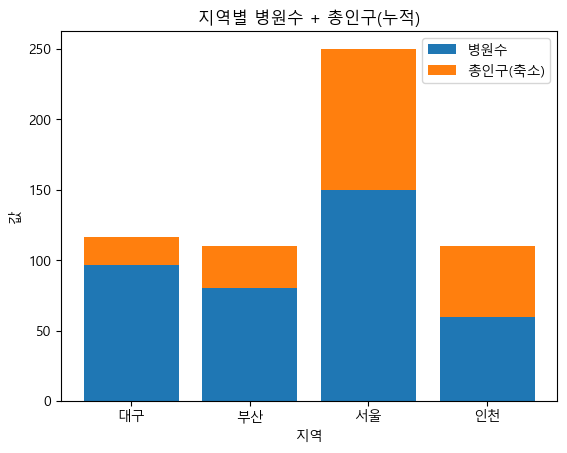

In [1]:
# 01. 반드시 pandas는 import하여 사용
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용
import matplotlib.pyplot as plt

# 02. 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000,300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150,80, 60]
})

# 03. 데이터 전처리를 위해 merge(병합)
# outer로 병합하면 df1과 df2의 합집합
merged = pd.merge(df1, df2, on="지역", how="outer")
merged
# 04. 결측치 처리
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# -----------------------------
# 세로막대 그래프

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 첫번째 막대
plt.bar(merged['지역'],merged['병원수'],label="병원수")
# 두번째 막대
# bottom => 기존 막대 위에 쌓음
plt.bar(merged['지역'],merged['총인구']/10000, bottom=merged["병원수"], label='총인구(축소)')

plt.title('지역별 병원수 + 총인구(누적)')
plt.xlabel('지역')
plt.ylabel('값')

# 범례 표시
plt.legend()

plt.show()

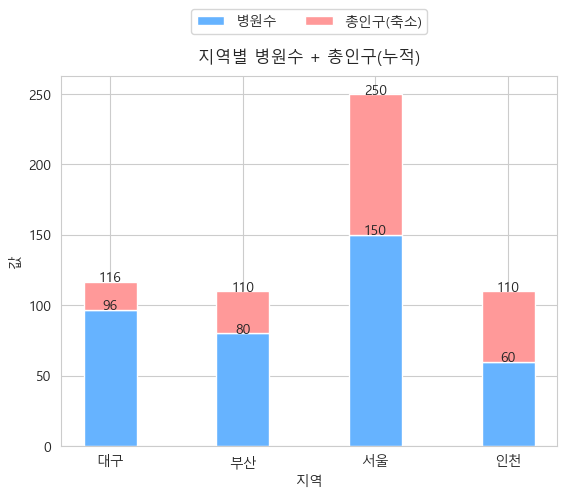

In [27]:
# 01. 반드시 pandas는 import하여 사용
import pandas as pd
# matplotlib 매트플롯립도 반드시 import하여 사용
import matplotlib.pyplot as plt
import seaborn as sns

# 02. 데이터 생성하기
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [1000000,300000, 200000]
})

df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150,80, 60]
})

# 03. 데이터 전처리를 위해 merge(병합)
# outer로 병합하면 df1과 df2의 합집합
merged = pd.merge(df1, df2, on="지역", how="outer")
merged
# 04. 결측치 처리
merged["총인구"] = merged["총인구"].fillna(merged["총인구"].mean())
merged["병원수"] = merged["병원수"].fillna(merged["병원수"].mean())

# -----------------------------
# 스타일
sns.set_style('whitegrid') # 배경 스타일 설정, dark : 그리드 없이 어두운 배경 지정
sns.set_palette('pastel') # 색상 스타일 지정, deep : 진하게

# 01. 한글 깨짐 방지 설정★
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 첫번째 막대
plt.bar(merged['지역'],merged['병원수'],label="병원수", color='#66b3ff',width=0.4)
# 첫번째 막대 데이터 레이블 값 출력
for i in range(len(merged)):
    plt.text(
        i, 
        merged['병원수'][i], 
        int(merged['병원수'][i]), 
        ha='center', 
    )
# 두번째 막대
# bottom => 기존 막대 위에 쌓음
plt.bar(merged['지역'],merged['총인구']/10000, bottom=merged["병원수"], label='총인구(축소)',color='#ff9999',width=0.4)
# 두번째 막대 데이터 레이블 값 출력
for i in range(len(merged)):
    tot = merged['병원수'][i] + merged['총인구'][i] / 10000
    plt.text(
        i, 
        tot, 
        int(tot), 
        ha='center'
    )

plt.title('지역별 병원수 + 총인구(누적)',pad=10)
plt.xlabel('지역')
plt.ylabel('값')

# 범례 표시
plt.legend(
    loc='upper center',
    bbox_to_anchor=(0.5,1.20),
    ncol=2 # 가로 나열
)

plt.show()